In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.extmath import randomized_svd

from src.utils.grid import build_xyz
from src.decomposition.rpca import randomized_rpca
from src.potential.poisson_solver import poisson_solve
from src.potential.charge_potential import v_analytic_gaussian
from src.potential.separable_density import (
    apply_exp_sum_to_separable_density,
    build_gaussian_kernel_1d,
)

In [24]:
N = 151
L = 20
alpha = 1.0

dx = L / N
eps = dx / 2
xyz = build_xyz(N, L)
R = np.sqrt(xyz[0]**2 + xyz[1]**2 + xyz[2]**2)

rho_grid = np.exp(-alpha * R**2)

print(f"rho max/min = {rho_grid.max():.4f} / {rho_grid.min():.4f}")

rho max/min = 1.0000 / 0.0000


## 指数関数による展開近似

In [25]:
from src.approximation.exp_sum.benchmark import BenchmarkRunner
from src.approximation.exp_sum.grid import LogUniformGrid
from src.approximation.exp_sum.models import ExponentialSum
from src.approximation.exp_sum.varpro import VarproOptimizer
from src.utils.cache import load_or_compute

fit_grid = LogUniformGrid(r_min=1e-2, r_max=2*np.sqrt(3)*L, n_points=2000)
eval_grid = LogUniformGrid(r_min=1e-2, r_max=2*np.sqrt(3)*L, n_points=2000)

ranks = [i for i in range(1, 31)]  # 偶数のランクを選択
nonneg = True
max_iter = 200000

optimizer = VarproOptimizer(
    fit_grid=fit_grid,
    eval_grid=eval_grid,
    nonneg=nonneg,
    max_iter=max_iter,
)

runner = BenchmarkRunner(optimizer=optimizer, ranks=ranks)

fits_cache_params = {
    "fit_grid": (fit_grid.r_min, fit_grid.r_max, fit_grid.n_points),
    "eval_grid": (eval_grid.r_min, eval_grid.r_max, eval_grid.n_points),
    "nonneg": nonneg,
    "max_iter": max_iter,
    "ranks": tuple(ranks),
}

fits = load_or_compute(
    namespace="exp_sum_fits",
    params=fits_cache_params,
    compute=runner.run,
)

# 表示 (キャッシュヒット時にも結果が見えるように)
print(f"{'R':>4}  {'L2 rel err':>14}  {'L\u221e rel err':>14}")
print("-" * 38)
for r in sorted(fits):
    print(f"{r:>4}  {fits[r].l2_error:>14.3e}  {fits[r].linf_error:>14.3e}")


[cache hit ] exp_sum_fits/7fbd88a87293cf6d.pkl
   R      L2 rel err      L∞ rel err
--------------------------------------
   1       8.980e-01       1.000e+00
   2       8.216e-01       1.000e+00
   3       7.544e-01       1.000e+00
   4       6.915e-01       1.000e+00
   5       6.302e-01       1.000e+00
   6       5.687e-01       1.000e+00
   7       5.052e-01       1.000e+00
   8       4.377e-01       1.000e+00
   9       3.629e-01       1.000e+00
  10       2.737e-01       9.996e-01
  11       1.655e-01       9.096e-01
  12       9.264e-02       6.439e-01
  13       5.405e-02       4.227e-01
  14       3.214e-02       2.722e-01
  15       1.921e-02       1.737e-01
  16       1.155e-02       1.109e-01
  17       5.339e-03       5.343e-02
  18       4.831e-03       3.708e-02
  19       2.914e-03       2.602e-02
  20       1.776e-03       1.471e-02
  21       1.069e-03       3.681e-03
  22       5.106e-04       2.901e-03
  23       7.958e-04       8.570e-03
  24       3.366e-04      

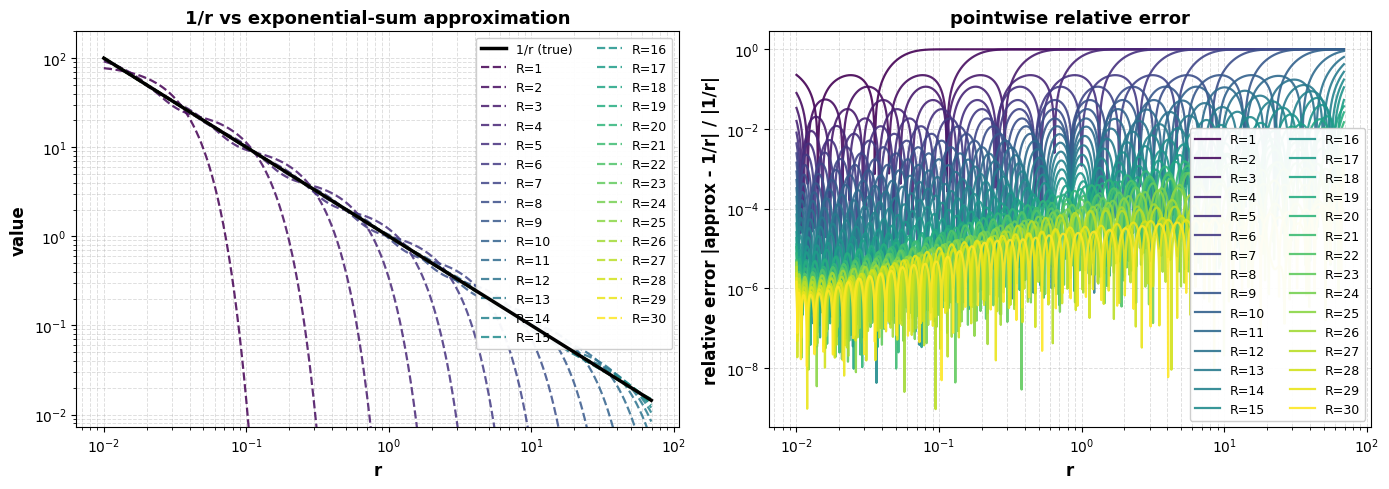

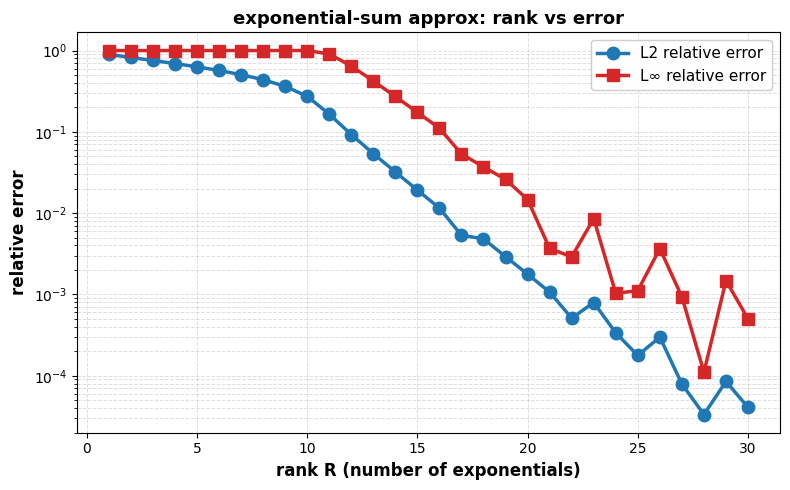

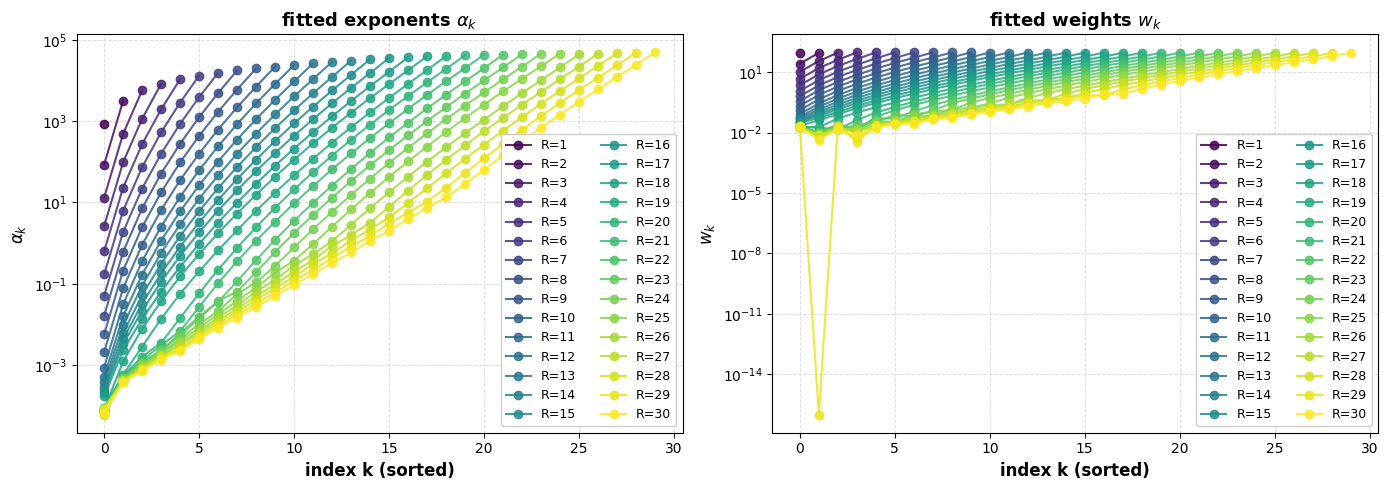

In [26]:
_UNDERFLOW_THRESHOLD = 1e-300


def _masked_loglog(ax, x, y, **kwargs):
    """y > threshold の点のみ loglog プロット（アンダーフロー除外）。"""
    valid = y > _UNDERFLOW_THRESHOLD
    if valid.any():
        ax.loglog(x[valid], y[valid], **kwargs)


def _make_colormap(n: int):
    cmap = plt.get_cmap("viridis")
    return [cmap(i / max(n - 1, 1)) for i in range(n)]


# ---------------------------------------------------------------------------
# 図1 + 図2: 近似カーブ と 点ごとの相対誤差
# ---------------------------------------------------------------------------

def plot_approximation(fits: dict, eval_grid: LogUniformGrid) -> None:
    r_eval = eval_grid.points
    f_true = 1.0 / r_eval
    ranks = sorted(fits.keys())
    colors = _make_colormap(len(ranks))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.loglog(r_eval, f_true, "k-", lw=2.5, label="1/r (true)", zorder=10)

    for color, r in zip(colors, ranks):
        approx = fits[r].evaluate(r_eval)
        _masked_loglog(ax, r_eval, approx, lw=1.6, ls="--",
                       color=color, alpha=0.85, label=f"R={r}")

    ax.set_ylim(f_true.min() * 0.5, f_true.max() * 2.0)
    ax.set_xlabel("r", fontsize=12, fontweight="bold")
    ax.set_ylabel("value", fontsize=12, fontweight="bold")
    ax.set_title("1/r vs exponential-sum approximation", fontsize=13, fontweight="bold")
    ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    ax2 = axes[1]
    for color, r in zip(colors, ranks):
        approx = fits[r].evaluate(r_eval)
        valid = approx > _UNDERFLOW_THRESHOLD
        if valid.any():
            rel_err = np.abs((approx[valid] - f_true[valid]) / f_true[valid])
            ax2.loglog(r_eval[valid], rel_err, "-", lw=1.6,
                       color=color, alpha=0.9, label=f"R={r}")

    ax2.set_xlabel("r", fontsize=12, fontweight="bold")
    ax2.set_ylabel("relative error |approx - 1/r| / |1/r|",
                   fontsize=12, fontweight="bold")
    ax2.set_title("pointwise relative error", fontsize=13, fontweight="bold")
    ax2.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax2.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 図3: ランク vs L2 / L∞ 誤差
# ---------------------------------------------------------------------------

def plot_rank_vs_error(fits: dict) -> None:
    ranks = sorted(fits.keys())
    l2_errs = [fits[r].l2_error for r in ranks]
    linf_errs = [fits[r].linf_error for r in ranks]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogy(ranks, l2_errs, "o-", markersize=9, lw=2.5,
                label="L2 relative error", color="C0")
    ax.semilogy(ranks, linf_errs, "s-", markersize=9, lw=2.5,
                label="L∞ relative error", color="C3")
    ax.set_xlabel("rank R (number of exponentials)", fontsize=12, fontweight="bold")
    ax.set_ylabel("relative error", fontsize=12, fontweight="bold")
    ax.set_title("exponential-sum approx: rank vs error",
                 fontsize=13, fontweight="bold")
    ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=11, loc="best", framealpha=0.95)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 図4: α_k と w_k の分布
# ---------------------------------------------------------------------------

def plot_param_distribution(fits: dict) -> None:
    ranks = sorted(fits.keys())
    colors = _make_colormap(len(ranks))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for color, r in zip(colors, ranks):
        idx = np.arange(r)
        axes[0].semilogy(idx, fits[r].alphas, "o-", color=color,
                         alpha=0.85, label=f"R={r}", markersize=6)
        axes[1].semilogy(idx, np.maximum(fits[r].weights, 1e-16), "o-",
                         color=color, alpha=0.85, label=f"R={r}", markersize=6)

    for ax, ylabel, title in zip(
        axes,
        [r"$\alpha_k$", r"$w_k$"],
        [r"fitted exponents $\alpha_k$", r"fitted weights $w_k$"],
    ):
        ax.set_xlabel("index k (sorted)", fontsize=12, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
        ax.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    plt.tight_layout()
    plt.show()


plot_approximation(fits, eval_grid)
plot_rank_vs_error(fits)
plot_param_distribution(fits)

In [27]:
V_analytic = v_analytic_gaussian(R, alpha)

ガウシアン密度を x, y, z 方向の外積和で表す

現在の `rho_grid` に行列を3軸方向から順次作用させる方法は一般的だが、各ステップで3Dテンソル全体を並べ替える。今回の密度はガウシアンなので、

$$
\rho(x,y,z)=\exp[-\alpha(x^2+y^2+z^2)]
=\rho_x(x)\rho_y(y)\rho_z(z)
$$

と分離できる。以降では密度を `(係数, ρx, ρy, ρz)` のリスト、つまりCP形式の外積和として持つ。


In [28]:
from src.potential.separable_density import make_gaussian_density_terms, materialize_density_terms

x_axis = xyz[0, :, 0, 0]
rho_terms = make_gaussian_density_terms(x_axis, alpha)
rho_grid_from_terms = materialize_density_terms(rho_terms)
print(
    "max |rho_grid - separable rho| =",
    np.max(np.abs(rho_grid - rho_grid_from_terms)),
)


max |rho_grid - separable rho| = 2.220446049250313e-16


対角成分の補正 ($1/r$ に対する近傍積分)

クーロンカーネル $1/r$ を離散化する際、同一セル内（$r=0$）の寄与を正しく評価する必要があります。指数和近似では中心での値が有限値 $\sum w_k$ となり、厳密な特異性を表現できません。
そこで、一辺 $dx$ の立方体領域の内部で $1/r$ を積分した解析値を用いて誤差を補正します。

単位立方体 $[-0.5, 0.5]^3$ における $1/r$ の体積積分は約 `2.38` となることが知られています。
これを用いて、対角成分の真の寄与は変数のスケール変換から以下のように求まります。

$$
K_{\text{diag}} = \frac{1}{dx^3} \iiint_{[-dx/2, dx/2]^3} \frac{1}{r} d^3r \approx \frac{2.38}{dx}
$$

実際の計算では、指数和近似がもつ対角成分 $\sum w_k$ と真の寄与 $2.38/dx$ の差分を加えることで近傍の誤差を補正します。

E_analytic(grid) = 1.236971e+01
   R |     1/r L2 | V err (no) | V err (corr) | E err (no) | E err (corr) |     Σw_k
------------------------------------------------------------------------------------------
   1 |  8.980e-01 |  9.989e-01 |    9.998e-01 |  9.844e-01 |    9.967e-01 |   84.204
   2 |  8.216e-01 |  9.978e-01 |    9.991e-01 |  9.684e-01 |    9.867e-01 |  116.845
   3 |  7.544e-01 |  9.921e-01 |    9.936e-01 |  8.848e-01 |    9.072e-01 |  138.888
   4 |  6.915e-01 |  9.723e-01 |    9.734e-01 |  5.955e-01 |    6.210e-01 |  155.939
   5 |  6.302e-01 |  9.252e-01 |    9.255e-01 |  1.017e-01 |    1.298e-01 |  170.011
   6 |  5.687e-01 |  8.306e-01 |    8.304e-01 |  8.914e-02 |    5.879e-02 |  182.078
   7 |  5.052e-01 |  6.311e-01 |    6.311e-01 |  1.996e-02 |    1.235e-02 |  192.695
   8 |  4.377e-01 |  2.655e-01 |    2.654e-01 |  2.271e-02 |    1.136e-02 |  202.208
   9 |  3.629e-01 |  1.308e-01 |    1.304e-01 |  3.965e-02 |    3.984e-03 |  210.849
  10 |  2.737e-01 |  7.917e

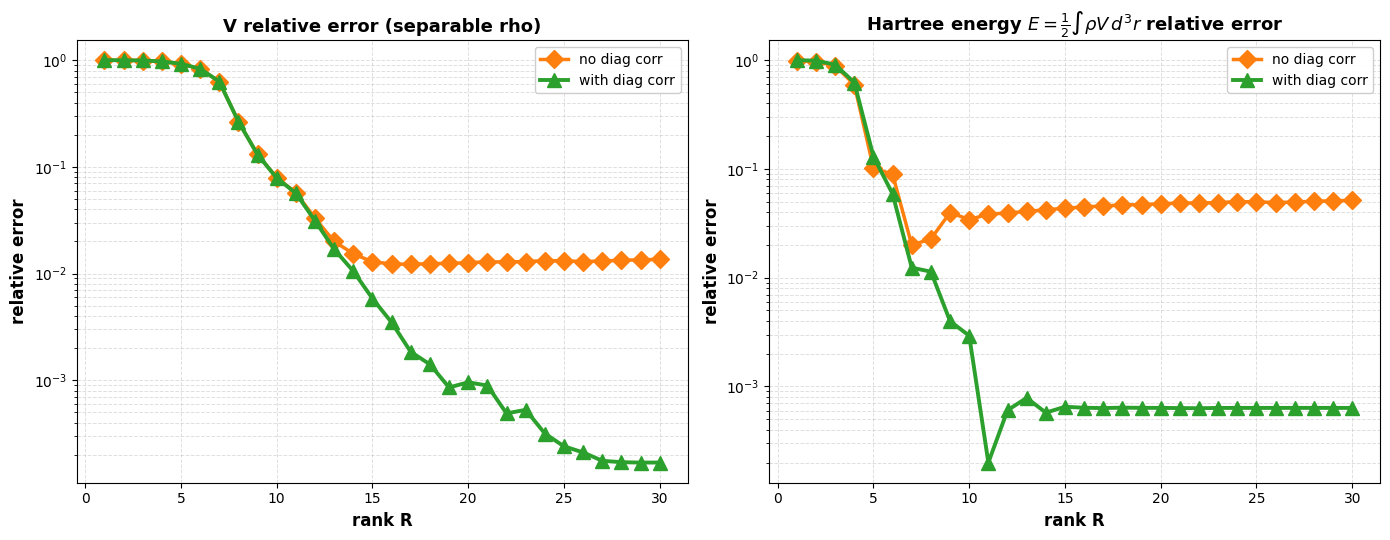

In [29]:
# ===== 各 R に対する V / E 相対誤差 (CP形式のρ + 対角補正あり / なし) =====
x_axis = xyz[0, :, 0, 0]
rho_terms = make_gaussian_density_terms(x_axis, alpha)
cell_int_const = 2.38                    # 立方体セル ∫ 1/r d³r / dx²
K_diag_true = cell_int_const / dx

# 解析エネルギー: E = (1/2) ∫ ρ V d³r を同じグリッド上のミッドポイント則で評価
E_analytic = 0.5 * np.sum(rho_grid * V_analytic) * dx**3

err_v_no_corr   = {}
err_v_with_corr = {}
err_e_no_corr   = {}
err_e_with_corr = {}

for r, fit in fits.items():
    V_no = apply_exp_sum_to_separable_density(
        fit=fit,
        x_axis=x_axis,
        density_terms=rho_terms,
        dx=dx,
        diag_coeff=0.0,
    )
    V_corr = apply_exp_sum_to_separable_density(
        fit=fit,
        x_axis=x_axis,
        density_terms=rho_terms,
        dx=dx,
        diag_coeff=K_diag_true - fit.weights.sum(),
    )

    err_v_no_corr[r]   = np.linalg.norm(V_no   - V_analytic) / np.linalg.norm(V_analytic)
    err_v_with_corr[r] = np.linalg.norm(V_corr - V_analytic) / np.linalg.norm(V_analytic)

    E_no   = 0.5 * np.sum(rho_grid * V_no)   * dx**3
    E_corr = 0.5 * np.sum(rho_grid * V_corr) * dx**3
    err_e_no_corr[r]   = abs(E_no   - E_analytic) / abs(E_analytic)
    err_e_with_corr[r] = abs(E_corr - E_analytic) / abs(E_analytic)

# ----- 表 -----
print(f"E_analytic(grid) = {E_analytic:.6e}")
print(f"{'R':>4s} | {'1/r L2':>10s} | "
      f"{'V err (no)':>10s} | {'V err (corr)':>12s} | "
      f"{'E err (no)':>10s} | {'E err (corr)':>12s} | {'Σw_k':>8s}")
print("-" * 90)
for r in sorted(fits):
    print(
        f"{r:>4d} | {fits[r].l2_error:>10.3e} | "
        f"{err_v_no_corr[r]:>10.3e} | {err_v_with_corr[r]:>12.3e} | "
        f"{err_e_no_corr[r]:>10.3e} | {err_e_with_corr[r]:>12.3e} | "
        f"{fits[r].weights.sum():>8.3f}"
    )

# ----- 図 -----
ranks_sorted = sorted(fits.keys())
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.semilogy(ranks_sorted, [err_v_no_corr[r]   for r in ranks_sorted],
            'D-',  markersize=9, lw=2.5, label='no diag corr',   color='C1')
ax.semilogy(ranks_sorted, [err_v_with_corr[r] for r in ranks_sorted],
            '^-',  markersize=10, lw=2.8, label='with diag corr', color='C2')
ax.set_xlabel('rank R', fontsize=12, fontweight='bold')
ax.set_ylabel('relative error', fontsize=12, fontweight='bold')
ax.set_title('V relative error (separable rho)', fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=10, loc='best', framealpha=0.95)

ax = axes[1]
ax.semilogy(ranks_sorted, [err_e_no_corr[r]   for r in ranks_sorted],
            'D-',  markersize=9, lw=2.5, label='no diag corr',   color='C1')
ax.semilogy(ranks_sorted, [err_e_with_corr[r] for r in ranks_sorted],
            '^-',  markersize=10, lw=2.8, label='with diag corr', color='C2')
ax.set_xlabel('rank R', fontsize=12, fontweight='bold')
ax.set_ylabel('relative error', fontsize=12, fontweight='bold')
ax.set_title(r'Hartree energy $E=\frac{1}{2}\int\rho V\,d^3r$ relative error',
             fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=10, loc='best', framealpha=0.95)

plt.tight_layout()
plt.show()


なぜ Rank 15 以降でエネルギーの誤差が打ち止め（プラトー）になるのか？

グリッド分割幅 ($dx$) による離散化誤差（数値積分の限界）が主な原因。

現在の計算では $N=151, L=20$ と設定されているため、グリッドの間隔は $dx \approx 0.132$ となります。エネルギーの計算は配列の単純な和 `np.sum(...) * dx**3`で行われています（リーマン和による区分求積法）。

Rank（指数関数の項数）を増やせば、擬似的な $1/r$ の関数自体はいくらでも真の関数に近づきますが、それを離散的なグリッド上で体積積分する際の「数値積分としての限界」が存在します。この離散化に起因する $O(dx^2)$ レベルの誤差が $10^{-3} \sim 10^{-4}$ のスケールにあるため、これ以上 Rank を上げて近似関数の質を良くしても、全体のエネルギー精度は向上しなくなる

Nを変えた離散化誤差の確認

打ち止めが指数和近似ではなく離散化誤差に支配されているかを見るため、複数の `N` で同じ計算を行う。参照値として連続系のガウシアン自己エネルギー

$$
E_{\mathrm{exact}}=\frac{\pi^{5/2}}{\sqrt{2}\,\alpha^{5/2}}
$$

も併記する。`grid ref vs exact` が `dx` とともに減少し、十分大きい `R` の誤差床もそれに追随すれば、プラトーは離散化誤差が主因だと判断できる。


pure discretization: E_grid_ref vs continuous exact
    N |         dx |      abs err |      rel err
--------------------------------------------------
   51 | 3.9216e-01 |    1.421e-14 |    1.149e-15
   75 | 2.6667e-01 |    1.776e-15 |    1.436e-16
  101 | 1.9802e-01 |    0.000e+00 |    0.000e+00
  151 | 1.3245e-01 |    1.776e-15 |    1.436e-16

exp-sum corrected energy error
   R |     N |  err vs grid ref |   err vs exact
--------------------------------------------------------------
  11 |    51 |        5.072e-03 |      5.072e-03
  11 |    75 |        2.055e-03 |      2.055e-03
  11 |   101 |        1.010e-03 |      1.010e-03
  11 |   151 |        1.997e-04 |      1.997e-04
  15 |    51 |        5.376e-03 |      5.376e-03
  15 |    75 |        2.546e-03 |      2.546e-03
  15 |   101 |        1.425e-03 |      1.425e-03
  15 |   151 |        6.511e-04 |      6.511e-04
  20 |    51 |        5.330e-03 |      5.330e-03
  20 |    75 |        2.536e-03 |      2.536e-03
  20 |   101 |    

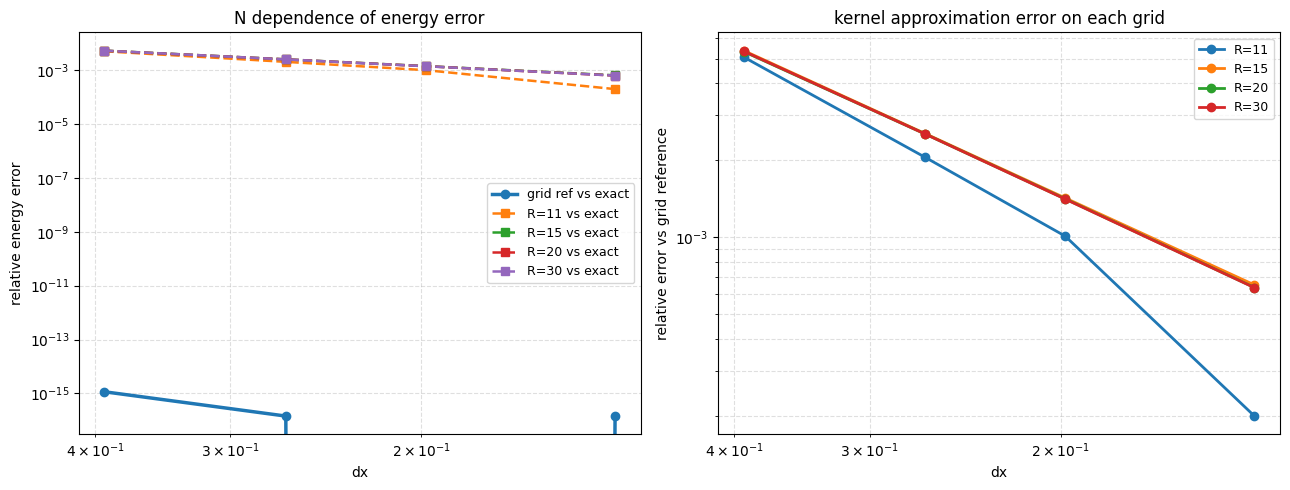

In [30]:
from src.potential.gaussian_discretization import compare_exp_sum_discretization

N_values = [51, 75, 101, 151]
ranks_to_check = [11, 15, 20, 30]
grid_rows, rank_rows_by_R = compare_exp_sum_discretization(
    N_values=N_values,
    L=L,
    alpha=alpha,
    fits=fits,
    ranks=ranks_to_check,
)

print("pure discretization: E_grid_ref vs continuous exact")
print(f"{'N':>5s} | {'dx':>10s} | {'abs err':>12s} | {'rel err':>12s}")
print("-" * 50)
for row in grid_rows:
    print(
        f"{row.N:>5d} | {row.dx:>10.4e} | "
        f"{row.abs_error:>12.3e} | {row.rel_error:>12.3e}"
    )

print("\nexp-sum corrected energy error")
print(f"{'R':>4s} | {'N':>5s} | {'err vs grid ref':>16s} | {'err vs exact':>14s}")
print("-" * 62)
for rank in ranks_to_check:
    for row in rank_rows_by_R[rank]:
        print(
            f"{rank:>4d} | {row.N:>5d} | "
            f"{row.err_vs_grid_ref:>16.3e} | {row.err_vs_cont_exact:>14.3e}"
        )

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
dx_values = np.array([row.dx for row in grid_rows])
grid_rel_errors = np.array([row.rel_error for row in grid_rows])

axes[0].loglog(dx_values, grid_rel_errors, 'o-', lw=2.5, label='grid ref vs exact')
for rank in ranks_to_check:
    rank_rel = np.array([row.err_vs_cont_exact for row in rank_rows_by_R[rank]])
    axes[0].loglog(dx_values, rank_rel, 's--', lw=1.8, label=f'R={rank} vs exact')
axes[0].invert_xaxis()
axes[0].set_xlabel('dx')
axes[0].set_ylabel('relative energy error')
axes[0].set_title('N dependence of energy error')
axes[0].grid(True, which='both', alpha=0.4, ls='--')
axes[0].legend(fontsize=9)

for rank in ranks_to_check:
    rank_grid = np.array([row.err_vs_grid_ref for row in rank_rows_by_R[rank]])
    axes[1].loglog(dx_values, rank_grid, 'o-', lw=2.0, label=f'R={rank}')
axes[1].invert_xaxis()
axes[1].set_xlabel('dx')
axes[1].set_ylabel('relative error vs grid reference')
axes[1].set_title('kernel approximation error on each grid')
axes[1].grid(True, which='both', alpha=0.4, ls='--')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


[cache hit ] rpca_svd_1d_kernels/0d487a1b9eb000a7.pkl
1D kernels factored. Calculating 3D potentials...


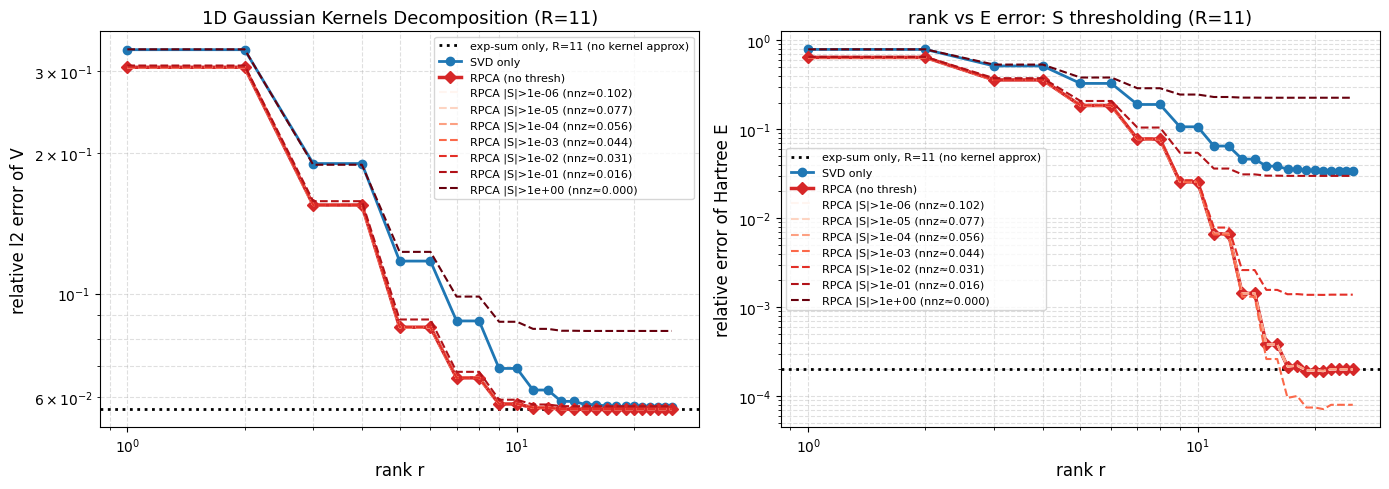

In [31]:
from src.approximation.exp_sum.separable import apply_1d_kernel_along_axis
from src.decomposition.rpca import randomized_rpca
from src.utils.metrics import v_e_errors
from src.utils.cache import load_or_compute

exp_sum_R = 11
fit = fits[exp_sum_R]
x_axis = xyz[0, :, 0, 0]

svd_ranks = [i for i in range(1, 26)]  # 各1DガウシアンのSVDランクを1から25まで試す
errors_v_svd_only = []
errors_e_svd_only = []
errors_v_rpca = []
errors_e_rpca = []

# αごとに1DガウシアンのSVD/RPCA分解を事前計算 (重いのでキャッシュする)
rpca_rank = N // 4
rpca_max_iter = 2000
rpca_tol = 1e-6

def _compute_kernels():
    K_1d_list_local = []
    RPCA_1d_list_local = []
    for alpha_k in fit.alphas:
        K_1D = build_gaussian_kernel_1d(alpha_k, x_axis)
        K_1d_list_local.append(K_1D)

        L_1d, S_1d = randomized_rpca(K_1D, rank=rpca_rank, max_iter=rpca_max_iter, tol=rpca_tol)
        U_L, S_L, Vt_L = np.linalg.svd(L_1d)
        U_s, S_s, Vt_s = np.linalg.svd(K_1D)

        RPCA_1d_list_local.append({
            'S_1d': S_1d, 'U_L': U_L, 'S_L': S_L, 'Vt_L': Vt_L,
            'U_s': U_s, 'S_s': S_s, 'Vt_s': Vt_s,
        })
    return {"K_1d_list": K_1d_list_local, "RPCA_1d_list": RPCA_1d_list_local}

kernels_cache_params = {
    "N": N,
    "L": L,
    "exp_sum_R": exp_sum_R,
    "alphas": np.asarray(fit.alphas, dtype=np.float64),
    "rpca_rank": rpca_rank,
}

kernels_data = load_or_compute(
    namespace="rpca_svd_1d_kernels",
    params=kernels_cache_params,
    compute=_compute_kernels,
)
K_1d_list = kernels_data["K_1d_list"]
RPCA_1d_list = kernels_data["RPCA_1d_list"]

print("1D kernels factored. Calculating 3D potentials...")

# 閾値のリスト
thresholds = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
errors_v_rpca_thresh = {thresh: [] for thresh in thresholds}
errors_e_rpca_thresh = {thresh: [] for thresh in thresholds}

for r in svd_ranks:
    V_svd = np.zeros_like(rho_grid)
    V_rpca_no_thresh = np.zeros_like(rho_grid)
    V_rpca_th = {thresh: np.zeros_like(rho_grid) for thresh in thresholds}

    for w_k, k_data in zip(fit.weights, RPCA_1d_list):
        # --- 1) SVD Only (1D) ---
        K_svd_1d = (k_data['U_s'][:, :r] * k_data['S_s'][:r]) @ k_data['Vt_s'][:r, :]

        # 3D畳み込み
        V_s_tmp = apply_1d_kernel_along_axis(K_svd_1d, rho_grid, axis=0)
        V_s_tmp = apply_1d_kernel_along_axis(K_svd_1d, V_s_tmp, axis=1)
        V_s_tmp = apply_1d_kernel_along_axis(K_svd_1d, V_s_tmp, axis=2)
        V_svd += w_k * V_s_tmp

        # --- 2) RPCA (1D L + S) No Threshold ---
        L_r_1d = (k_data['U_L'][:, :r] * k_data['S_L'][:r]) @ k_data['Vt_L'][:r, :]
        K_rpca_1d = L_r_1d + k_data['S_1d']

        V_r_tmp = apply_1d_kernel_along_axis(K_rpca_1d, rho_grid, axis=0)
        V_r_tmp = apply_1d_kernel_along_axis(K_rpca_1d, V_r_tmp, axis=1)
        V_r_tmp = apply_1d_kernel_along_axis(K_rpca_1d, V_r_tmp, axis=2)
        V_rpca_no_thresh += w_k * V_r_tmp
        
        # --- 3) RPCA with Thresholding on S ---
        for thresh in thresholds:
            S_thresh = np.where(np.abs(k_data['S_1d']) > thresh, k_data['S_1d'], 0.0)
            K_rpca_th_1d = L_r_1d + S_thresh
            
            V_th_tmp = apply_1d_kernel_along_axis(K_rpca_th_1d, rho_grid, axis=0)
            V_th_tmp = apply_1d_kernel_along_axis(K_rpca_th_1d, V_th_tmp, axis=1)
            V_th_tmp = apply_1d_kernel_along_axis(K_rpca_th_1d, V_th_tmp, axis=2)
            V_rpca_th[thresh] += w_k * V_th_tmp

    # dx**3 & 対角補正
    V_svd_corr = (V_svd + (K_diag_true - fit.weights.sum()) * rho_grid) * dx**3
    V_rpca_no_corr = (V_rpca_no_thresh + (K_diag_true - fit.weights.sum()) * rho_grid) * dx**3

    # 誤差の記録
    err_v_s, err_e_s = v_e_errors(V_svd_corr, V_analytic, rho_grid, dx)
    errors_v_svd_only.append(err_v_s)
    errors_e_svd_only.append(err_e_s)

    err_v_rpca_no, err_e_rpca_no = v_e_errors(V_rpca_no_corr, V_analytic, rho_grid, dx)
    errors_v_rpca.append(err_v_rpca_no)
    errors_e_rpca.append(err_e_rpca_no)
    
    for thresh in thresholds:
        V_rpca_th_corr = (V_rpca_th[thresh] + (K_diag_true - fit.weights.sum()) * rho_grid) * dx**3
        err_v_th, err_e_th = v_e_errors(V_rpca_th_corr, V_analytic, rho_grid, dx)
        errors_v_rpca_thresh[thresh].append(err_v_th)
        errors_e_rpca_thresh[thresh].append(err_e_th)

# プロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# colors / linestyles for thresholds
cmap = plt.get_cmap("Reds")
colors = [cmap(i / max(len(thresholds) - 1, 1)) for i in range(len(thresholds))]

# 指数和近似のみ（カーネル近似なし）の参照誤差を点線で表示
ref_label = f'exp-sum only, R={exp_sum_R} (no kernel approx)'
axes[0].axhline(err_v_with_corr[exp_sum_R], ls=':', lw=2.0, color='k', label=ref_label)
axes[1].axhline(err_e_with_corr[exp_sum_R], ls=':', lw=2.0, color='k', label=ref_label)

axes[0].loglog(svd_ranks, errors_v_svd_only, 'o-', lw=2, label='SVD only')
axes[0].loglog(svd_ranks, errors_v_rpca, 'D-', lw=2.5, color='C3', label='RPCA (no thresh)')
for i, thresh in enumerate(thresholds):
    # compute median nnz ratio for legend roughly
    mean_nnz = np.mean([np.count_nonzero(np.abs(k_data['S_1d']) > thresh) / k_data['S_1d'].size for k_data in RPCA_1d_list])
    axes[0].loglog(svd_ranks, errors_v_rpca_thresh[thresh], '--', color=colors[i], label=f'RPCA |S|>{thresh:.0e} (nnz≈{mean_nnz:.3f})')

axes[0].set_xlabel('rank r', fontsize=12)
axes[0].set_ylabel('relative l2 error of V', fontsize=12)
axes[0].set_title(f'1D Gaussian Kernels Decomposition (R={exp_sum_R})', fontsize=13)
axes[0].grid(True, which='both', alpha=0.4, ls='--')
axes[0].legend(fontsize=8, loc='best')

axes[1].loglog(svd_ranks, errors_e_svd_only, 'o-', lw=2, label='SVD only')
axes[1].loglog(svd_ranks, errors_e_rpca, 'D-', lw=2.5, color='C3', label='RPCA (no thresh)')
for i, thresh in enumerate(thresholds):
    mean_nnz = np.mean([np.count_nonzero(np.abs(k_data['S_1d']) > thresh) / k_data['S_1d'].size for k_data in RPCA_1d_list])
    axes[1].loglog(svd_ranks, errors_e_rpca_thresh[thresh], '--', color=colors[i], label=f'RPCA |S|>{thresh:.0e} (nnz≈{mean_nnz:.3f})')

axes[1].set_xlabel('rank r', fontsize=12)
axes[1].set_ylabel('relative error of Hartree E', fontsize=12)
axes[1].set_title(f'rank vs E error: S thresholding (R={exp_sum_R})', fontsize=13)
axes[1].grid(True, which='both', alpha=0.4, ls='--')
axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()
plt.show()

## 計算時間の比較 (3D 指数和近似 / PyTorch バックエンド)

1D の議論を3次元に拡張する。
1つの Gaussian カーネル `K (N×N)` を `ρ (N,N,N)` の各軸に作用させるコストを測る。
アルゴリズム間の純粋な計算量の差を評価するため、すべての経路を **PyTorch テンソル演算** に統一して計測する。

- **full**: そのまま N×N の `K` を tensordot で適用。各軸 O(N⁴)。
- **low-rank (順序ミス)**: `K_r = (U_r Σ_r) @ V_rᵀ` を **再構成してから** `tensordot` する。N×N に戻ってしまうので O(N⁴) に逆戻り。
- **low-rank (正しい順序)**: `K_r` を組み立てず、`V_rᵀ` を先にテンソルに作用させて軸の次元を r に落とし、最後に `U_r` で戻す mode-n product。**O(rN³)**。
- **rPCA**: `K ≈ L + S`。`L` は rank-r で正しい順序。`S` は閾値でゼロ化した後、非ゼロ率が 10% 以下なら **PyTorch の Sparse CSR テンソル (`torch.sparse.mm`)** を使用、そうでなければ dense tensordot を使用する。

> **注**: NumPy / SciPy (CPU) 同士等の比較では、関数や機能ごとのマルチスレッド（OpenMP）の使われ方やオーバーヘッドが異なり、純粋なアルゴリズムの差を評価しにくくなることがある。本計測ではすべての経路を PyTorch のテンソル操作にそろえることで、ライブラリバックエンドの実装差を排除した公平なパフォーマンス比較を行っている。

`%%timeit -r 7` で測定。

In [32]:
import torch
import os
from src.approximation.torch_kernels import (
    apply_dense_axis,
    apply_low_rank_axis,
    to_float64_tensor,
)

# ---- 計測用パラメータ ----
r_bench = 15 # SVD/RPCAのランク（1Dガウシアンあたり）
tau_bench = 1e-2

# ---- データの準備（PyTorch テンソルへの変換を同時に行う） ----
rpca_dense_data_pt = []
rpca_lowrank_only_data_pt = []
lowrank_data_pt = []
full_kernels_pt = []

lowrank_only_count = 0
dense_count = 0

for i, (alpha_k, w_k) in enumerate(zip(fit.alphas, fit.weights)):
    K_1d = K_1d_list[i]
    k_data = RPCA_1d_list[i]

    # SVD
    Ur = k_data['U_s'][:, :r_bench]
    sr = k_data['S_s'][:r_bench]
    Vtr = k_data['Vt_s'][:r_bench, :]

    # RPCA (L+S)
    UrL = k_data['U_L'][:, :r_bench]
    srL = k_data['S_L'][:r_bench]
    VtrL = k_data['Vt_L'][:r_bench, :]

    S_1d = k_data['S_1d']
    S_thr = np.where(np.abs(S_1d) > tau_bench, S_1d, 0.0)
    nnz = np.count_nonzero(S_thr)

    # 共通の LowRank データ (PyTorch化)
    Ur_pt = to_float64_tensor(Ur)
    sr_pt = to_float64_tensor(sr)
    Vtr_pt = to_float64_tensor(Vtr)
    lowrank_data_pt.append((w_k, Ur_pt, sr_pt, Vtr_pt))

    K_1d_pt = to_float64_tensor(K_1d)
    full_kernels_pt.append((w_k, K_1d_pt))

    UrL_pt = to_float64_tensor(UrL)
    srL_pt = to_float64_tensor(srL)
    VtrL_pt = to_float64_tensor(VtrL)

    if nnz == 0:
        rpca_lowrank_only_data_pt.append((w_k, UrL_pt, srL_pt, VtrL_pt))
        lowrank_only_count += 1
    else:
        S_thr_pt = to_float64_tensor(S_thr)
        rpca_dense_data_pt.append((w_k, UrL_pt, srL_pt, VtrL_pt, S_thr_pt))
        dense_count += 1

print(
    f"rpca path: dense={dense_count}, lowrank_only={lowrank_only_count} "
    "(backend = PyTorch)"
)

rpca path: dense=10, lowrank_only=1 (backend = PyTorch)


In [ ]:
from src.approximation.torch_kernels import (
    apply_exp_sum_3d_full,
    apply_exp_sum_3d_lowrank_naive,
    apply_exp_sum_3d_lowrank,
    apply_exp_sum_3d_rpca,
    apply_exp_sum_3d_rpca_l_only,
    apply_exp_sum_3d_rpca_s_only,
)

rho_pt = to_float64_tensor(rho_grid)

# ウォームアップ
_ = apply_exp_sum_3d_full(rho_pt, full_kernels_pt)
_ = apply_exp_sum_3d_lowrank_naive(rho_pt, lowrank_data_pt)
_ = apply_exp_sum_3d_lowrank(rho_pt, lowrank_data_pt)
_ = apply_exp_sum_3d_rpca(
    rho_pt, rpca_lowrank_only_data_pt, rpca_dense_data_pt,
)

In [ ]:
%%timeit -n 10 -r 10
# (1) full: K (N×N) を3軸に tensordot -> O(3 N^4)
apply_exp_sum_3d_full(rho_pt, full_kernels_pt)

In [ ]:
%%timeit -n 10 -r 10
# (2) low-rank だが順序ミス: K_r を組み立て直して適用 -> O(N^4) のまま
apply_exp_sum_3d_lowrank_naive(rho_pt, lowrank_data_pt)

In [ ]:
%%timeit -n 10 -r 10
# (3) low-rank で正しい順序: mode-n product -> O(r N^3)
apply_exp_sum_3d_lowrank(rho_pt, lowrank_data_pt)

In [ ]:
%%timeit -n 10 -r 10
# (4) rPCA: L は低ランク mode-n product、S は dense tensordot
apply_exp_sum_3d_rpca(
    rho_pt, rpca_lowrank_only_data_pt, rpca_dense_data_pt,
)

In [ ]:
%%timeit -n 10 -r 10
# (4a) rPCA: L成分のみ (全R項) -> O(r N^3)
apply_exp_sum_3d_rpca_l_only(
    rho_pt, rpca_lowrank_only_data_pt, rpca_dense_data_pt,
)

In [ ]:
%%timeit -n 10 -r 10
# (4b) rPCA: S成分のみ (dense項のみ) -> O(N^4) dense
apply_exp_sum_3d_rpca_s_only(rho_pt, rpca_dense_data_pt)

(5) CP-ρ パス: ρ の分離性を利用して全計算を 1D 演算に還元

ρ を CP 形式（外積和）で持つと、各指数和項 k のカーネルは **1D マトリクス–ベクトル積**だけで V が構成できる。

$$
V(x,y,z) = dx^3 \sum_k w_k \sum_m c_m
\bigl(\underbrace{K_k \rho_m^x}_{\text{1D matvec}}\bigr) \otimes
\bigl(K_k \rho_m^y\bigr) \otimes
\bigl(K_k \rho_m^z\bigr)
$$

エネルギー E は V を 3D 配列に具現化せず**純粋な 1D 演算**で直接求まる。

$$
E = \frac{dx^3}{2} \sum_k w_k \sum_{m,n} c_m c_n
\langle\rho_n^x,\, K_k\rho_m^x\rangle
\langle\rho_n^y,\, K_k\rho_m^y\rangle
\langle\rho_n^z,\, K_k\rho_m^z\rangle
$$

コスト比較（K = exp-sum ランク, M = CP ランク, r = SVD 低ランク）:

| 手法 | コスト |
|------|--------|
| full | O(K N⁴) |
| low-rank 正しい順序 | O(K r N³) |
| **(5a) CP-ρ → V** | **O(K M N³)** ※外積の具現化が O(N³) |
| **(5b) CP-ρ → E のみ** | **O(K M² N²)** ※3D 配列不要・純粋 1D |

今回は M=1（Gaussian ρ は厳密に分離可能）なので、  
(5a) は low-rank (r=15) より **15× 速い**、(5b) は外積具現化もなく**さらに速い**ことが期待できる。

`rho_terms` は既存の `make_gaussian_density_terms` が返す `SeparableDensityTerm` リスト  
（`.coefficient`, `.fx`, `.fy`, `.fz`）をそのまま利用する。

In [41]:
# ===== (5) CP-ρ パスの精度検証 =====
# (5a) V: 既存の apply_exp_sum_to_separable_density がすでに CP-ρ → V を実装済み
diag_coeff_bench = K_diag_true - fit.weights.sum()
V_cp = apply_exp_sum_to_separable_density(
    fit=fit,
    x_axis=x_axis,
    density_terms=rho_terms,
    dx=dx,
    diag_coeff=diag_coeff_bench,
)
err_v_cp = np.linalg.norm(V_cp - V_analytic) / np.linalg.norm(V_analytic)

# (5b) E only: V を 3D 配列に具現化せず純粋な 1D 内積だけで計算
def compute_hartree_energy_cp_rho(fit, rho_terms, K_1d_list, dx, diag_coeff=0.0):
    """
    E = (dx³/2) Σ_k w_k Σ_{m,n} c_m c_n
          <ρn_x, K_k ρm_x> <ρn_y, K_k ρm_y> <ρn_z, K_k ρm_z>
      + (dx³/2) diag_coeff Σ_{m,n} c_m c_n <ρn_x, ρm_x> <ρn_y, ρm_y> <ρn_z, ρm_z>
    3D 配列を一切使わず 1D 演算のみで完結する。
    """
    E = 0.0
    for w_k, K_k in zip(fit.weights, K_1d_list):
        for t_m in rho_terms:
            vx = K_k @ t_m.fx
            vy = K_k @ t_m.fy
            vz = K_k @ t_m.fz
            for t_n in rho_terms:
                E += (w_k * t_m.coefficient * t_n.coefficient
                      * (t_n.fx @ vx) * (t_n.fy @ vy) * (t_n.fz @ vz))
    E *= 0.5 * dx**6

    if diag_coeff != 0.0:
        E_diag = 0.0
        for t_m in rho_terms:
            for t_n in rho_terms:
                E_diag += (t_m.coefficient * t_n.coefficient
                           * (t_n.fx @ t_m.fx) * (t_n.fy @ t_m.fy) * (t_n.fz @ t_m.fz))
        E += 0.5 * diag_coeff * E_diag * dx**6
    return E

E_cp = compute_hartree_energy_cp_rho(
    fit, rho_terms, K_1d_list, dx, diag_coeff=diag_coeff_bench
)
err_e_cp = abs(E_cp - E_analytic) / abs(E_analytic)

print(f"CP-ρ → V  relative error: {err_v_cp:.3e}  (= err_v_with_corr[{exp_sum_R}] from cell above)")
print(f"CP-ρ → E  relative error: {err_e_cp:.3e}  (E_analytic = {E_analytic:.6e})")

CP-ρ → V  relative error: 5.655e-02  (= err_v_with_corr[11] from cell above)
CP-ρ → E  relative error: 1.997e-04  (E_analytic = 1.236971e+01)


In [ ]:
from src.approximation.cp_coulomb import (
    apply_cp_rho_V,
    apply_cp_rho_E,
    apply_cp_rho_V_rpca,
    apply_cp_rho_E_rpca,
)

# ===== (5) CP-ρ PyTorch 版: タイミング計測の準備 =====

rho_terms_pt = [
    (t.coefficient, to_float64_tensor(t.fx),
     to_float64_tensor(t.fy), to_float64_tensor(t.fz))
    for t in rho_terms
]
kernel_list_pt = [
    (w, to_float64_tensor(K))
    for w, K in zip(fit.weights, K_1d_list)
]

# ウォームアップ
_ = apply_cp_rho_V(rho_terms_pt, kernel_list_pt)
_ = apply_cp_rho_E(rho_terms_pt, kernel_list_pt, dx)
_ = apply_cp_rho_V_rpca(
    rho_terms_pt, rpca_lowrank_only_data_pt, rpca_dense_data_pt,
)
_ = apply_cp_rho_E_rpca(
    rho_terms_pt, rpca_lowrank_only_data_pt, rpca_dense_data_pt, dx,
)
print("CP-ρ PyTorch functions ready.")

In [ ]:
%%timeit -n 10 -r 10
# (5a) CP-ρ → V: 1D matvec + 外積具現化 -> O(K M N^3), M=1
apply_cp_rho_V(rho_terms_pt, kernel_list_pt)

In [ ]:
%%timeit -n 10 -r 10
# (5b) CP-ρ → E only: 純粋 1D 演算のみ -> O(K M^2 N^2), M=1
apply_cp_rho_E(rho_terms_pt, kernel_list_pt, dx)

(5c/5d) CP-ρ + rPCA の組み合わせ

1D カーネルに rPCA 分解 $K_k \approx L_k + S_k$ を適用し、CP-ρ の 1D matvec と組み合わせる。

- **L 成分**: $L_k\,f = U_k\,(s_k \odot (V_k^\top f))$ → O(rN)
- **S 成分**: $S_k\,f$ → O(N²)（S≠0 の項のみ）

| 手法 | matvec コスト | V 計算 | E 計算 |
|------|------|------|------|
| CP-ρ full | O(K N²) | O(K N³) | O(K N²) |
| **CP-ρ + rPCA** | **O(K_L rN + K_S N²)** | **O(K N³)** | **O(K_L rN + K_S N²)** |

V は外積の具現化 O(N³) がボトルネックなため改善は小さい。E は matvec がボトルネックなため L 項で O(rN) への削減効果あり。

In [ ]:
# ===== CP-ρ + rPCA 精度検証 =====

# (5c) V: rPCA matvec + 外積
V_rpca_raw = apply_cp_rho_V_rpca(
    rho_terms_pt, rpca_lowrank_only_data_pt, rpca_dense_data_pt,
).numpy()
V_cp_rpca = (V_rpca_raw + diag_coeff_bench * rho_grid) * dx**3
err_v_cp_rpca = (
    np.linalg.norm(V_cp_rpca - V_analytic)
    / np.linalg.norm(V_analytic)
)

# (5d) E: rPCA matvec + 1D 内積（対角補正を別途加算）
E_main = apply_cp_rho_E_rpca(
    rho_terms_pt, rpca_lowrank_only_data_pt, rpca_dense_data_pt, dx,
).item()
E_diag = 0.0
for t_m in rho_terms:
    for t_n in rho_terms:
        E_diag += (
            t_m.coefficient * t_n.coefficient
            * (t_n.fx @ t_m.fx)
            * (t_n.fy @ t_m.fy)
            * (t_n.fz @ t_m.fz)
        )
E_cp_rpca = E_main + 0.5 * diag_coeff_bench * E_diag * dx**6
err_e_cp_rpca = abs(E_cp_rpca - E_analytic) / abs(E_analytic)

print(f"CP-ρ+rPCA → V  relative error: {err_v_cp_rpca:.3e}")
print(f"CP-ρ+rPCA → E  relative error: {err_e_cp_rpca:.3e}")
print()
print(f"参照 CP-ρ full  → V: {err_v_cp:.3e},  E: {err_e_cp:.3e}")
print(f"参照 rPCA only  → V: {err_v_with_corr[exp_sum_R]:.3e}")

In [ ]:
%%timeit -n 10 -r 10
# (5c) CP-ρ + rPCA → V: rPCA matvec + 外積具現化
apply_cp_rho_V_rpca(
    rho_terms_pt, rpca_lowrank_only_data_pt, rpca_dense_data_pt,
)

In [ ]:
%%timeit -n 10 -r 10
# (5d) CP-ρ + rPCA → E only: rPCA matvec + 純粋 1D 演算
apply_cp_rho_E_rpca(
    rho_terms_pt, rpca_lowrank_only_data_pt, rpca_dense_data_pt, dx,
)